#                          Flight Price Prediction Using Machine Learning

## Objective

#### To analyze flight-related factors and build a regression model to predict ticket prices accurately

In [65]:
import pandas as pd 
df = pd.read_csv ("flight_price.csv")

print(df.shape)
df.head()

(300257, 25)


,Unnamed: 0,airline,from,to,price,class_category,class,day,month,flight_no,...,airline_index,route_index,duration_in_min,stops,stops_category,arr_daytime,arr_daytime_category,dep_daytime,dep_daytime_category,month_category
0,0,SpiceJet,Delhi,Mumbai,5953,Economy,0,11,2,SG-8709,...,4,14,130,0,Non-stop,0,Night Arrival,1,Daytime Departure,February
1,1,SpiceJet,Delhi,Mumbai,5953,Economy,0,11,2,SG-8157,...,4,14,140,0,Non-stop,1,Daytime Arrival,1,Daytime Departure,February
2,2,AirAsia,Delhi,Mumbai,5956,Economy,0,11,2,I5-764,...,1,14,130,0,Non-stop,1,Daytime Arrival,0,Night Departure,February
3,3,Vistara,Delhi,Mumbai,5955,Economy,0,11,2,UK-995,...,7,14,135,0,Non-stop,1,Daytime Arrival,1,Daytime Departure,February
4,4,Vistara,Delhi,Mumbai,5955,Economy,0,11,2,UK-963,...,7,14,140,0,Non-stop,1,Daytime Arrival,1,Daytime Departure,February


In [66]:
df.columns

Index(['Unnamed: 0', 'airline', 'from', 'to', 'price', 'class_category',
       'class', 'day', 'month', 'flight_no', 'route', 'dep_hour', 'arr_hour',
       'dep_period', 'arr_period', 'airline_index', 'route_index',
       'duration_in_min', 'stops', 'stops_category', 'arr_daytime',
       'arr_daytime_category', 'dep_daytime', 'dep_daytime_category',
       'month_category'],
      dtype='object')

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300257 entries, 0 to 300256
Data columns (total 25 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   Unnamed: 0            300257 non-null  int64 
 1   airline               300257 non-null  object
 2   from                  300257 non-null  object
 3   to                    300257 non-null  object
 4   price                 300257 non-null  int64 
 5   class_category        300257 non-null  object
 6   class                 300257 non-null  int64 
 7   day                   300257 non-null  int64 
 8   month                 300257 non-null  int64 
 9   flight_no             300257 non-null  object
 10  route                 300257 non-null  object
 11  dep_hour              300257 non-null  int64 
 12  arr_hour              300257 non-null  int64 
 13  dep_period            300257 non-null  object
 14  arr_period            300257 non-null  object
 15  airline_index    

In [68]:
df.isnull().sum()

Unnamed: 0              0
airline                 0
from                    0
to                      0
price                   0
class_category          0
class                   0
day                     0
month                   0
flight_no               0
route                   0
dep_hour                0
arr_hour                0
dep_period              0
arr_period              0
airline_index           0
route_index             0
duration_in_min         0
stops                   0
stops_category          0
arr_daytime             0
arr_daytime_category    0
dep_daytime             0
dep_daytime_category    0
month_category          0
dtype: int64

In [69]:
df.duplicated().sum()

np.int64(0)

In [70]:
df['price'].describe()

count    300257.000000
mean      20883.926526
std       22695.990185
min        1105.000000
25%        4783.000000
50%        7425.000000
75%       42521.000000
max      123071.000000
Name: price, dtype: float64

## Insight
The average flight price is approximately ₹20,884. Prices range from ₹1,105 to ₹1,23,071, showing a wide variation in ticket prices.

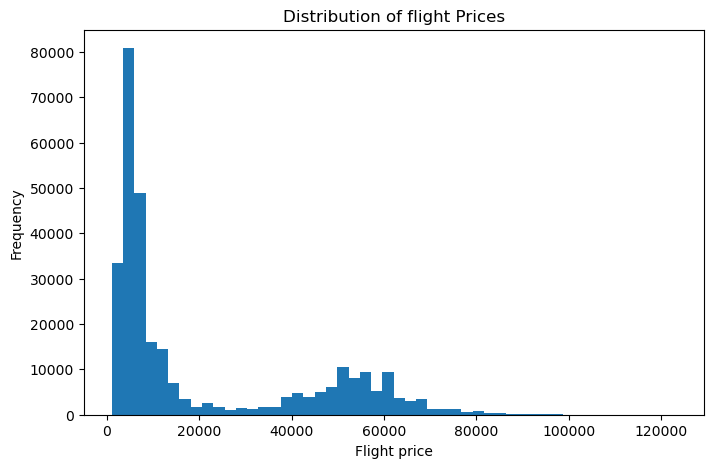

In [71]:
## Price distribution

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['price'], bins=50)
plt.xlabel('Flight price')
plt.ylabel('Frequency')
plt.title('Distribution of flight Prices')
plt.show()

## Insight:
The price distribution is right-skewed, with most flight prices concentrated at lower values and fewer flights having very high prices.

In [72]:
## Average price by Airline

df.groupby('airline')['price'].mean().sort_values(ascending=False)

airline
Vistara      30396.536302
Air India    23506.647217
SpiceJet      6179.278881
GO FIRST      5652.007595
Indigo        5324.216303
StarAir       4932.655738
AirAsia       4091.072742
Trujet        3244.634146
Name: price, dtype: float64

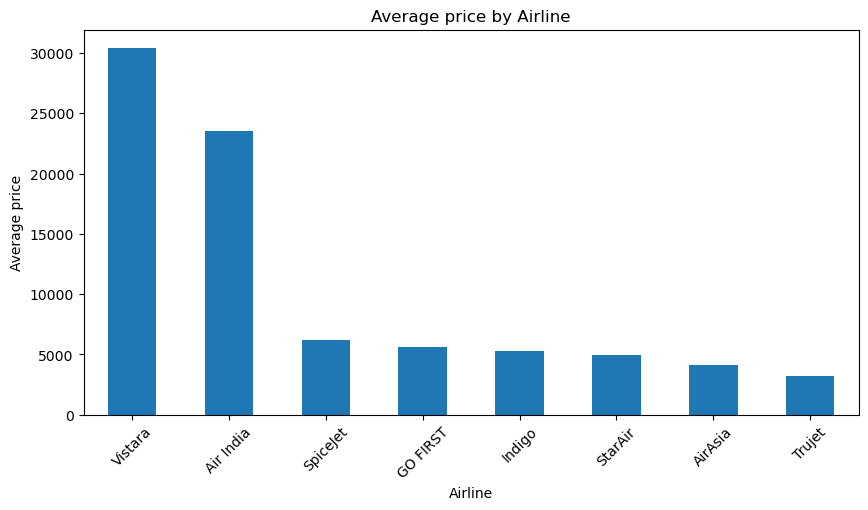

In [73]:
df.groupby('airline')['price'].mean().sort_values(ascending=False).plot(
    kind= 'bar',
    figsize=(10,5)
)


plt.xlabel('Airline')
plt.ylabel('Average price')
plt.title('Average price by airline')
plt.xticks(rotation=45)
plt.show()

## Insight:
Flight prices vary significantly between airlines. Vistara has the highest average price, while Trujet has the lowest average price.

In [74]:
## Average price by class
df.groupby('class_category')['price'].mean().sort_values(ascending=False)

class_category
Business    52540.081124
Economy      6571.217116
Name: price, dtype: float64

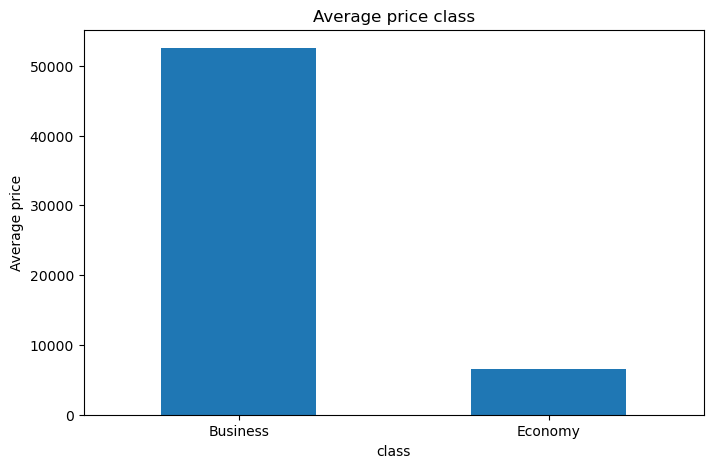

In [75]:
df.groupby('class_category')['price'].mean().sort_values(ascending=False).plot(
    kind='bar',
    figsize=(8,5)
)

plt.xlabel('class')
plt.ylabel('Average price')
plt.title('Average price class')
plt.xticks(rotation=0)
plt.show()

## Insight:
Business class has a much higher average price than Economy class, showing that ticket class is an important factor affecting price.

In [76]:
## Stops vs price

df.groupby('stops_category')['price'].mean().sort_values(ascending=False)

stops_category
1-Stop            22896.527113
Multiple-Stops    14113.450775
Non-stop           9368.465237
Name: price, dtype: float64

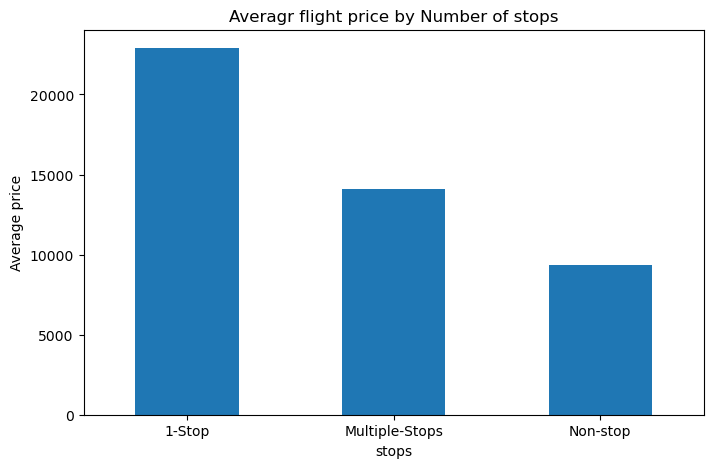

In [77]:
df.groupby('stops_category')['price'].mean().sort_values(ascending=False).plot(
    kind='bar',
    figsize=(8,5)
)

plt.xlabel('stops')
plt.ylabel('Average price')
plt.title('Averagr flight price by Number of stops')
plt.xticks(rotation=0)
plt.show()

## Insight
Flight prices differ based on the number of stops. 1-stop flights have the highest average price, while non-stop flights have the lowest average price in this dataset.

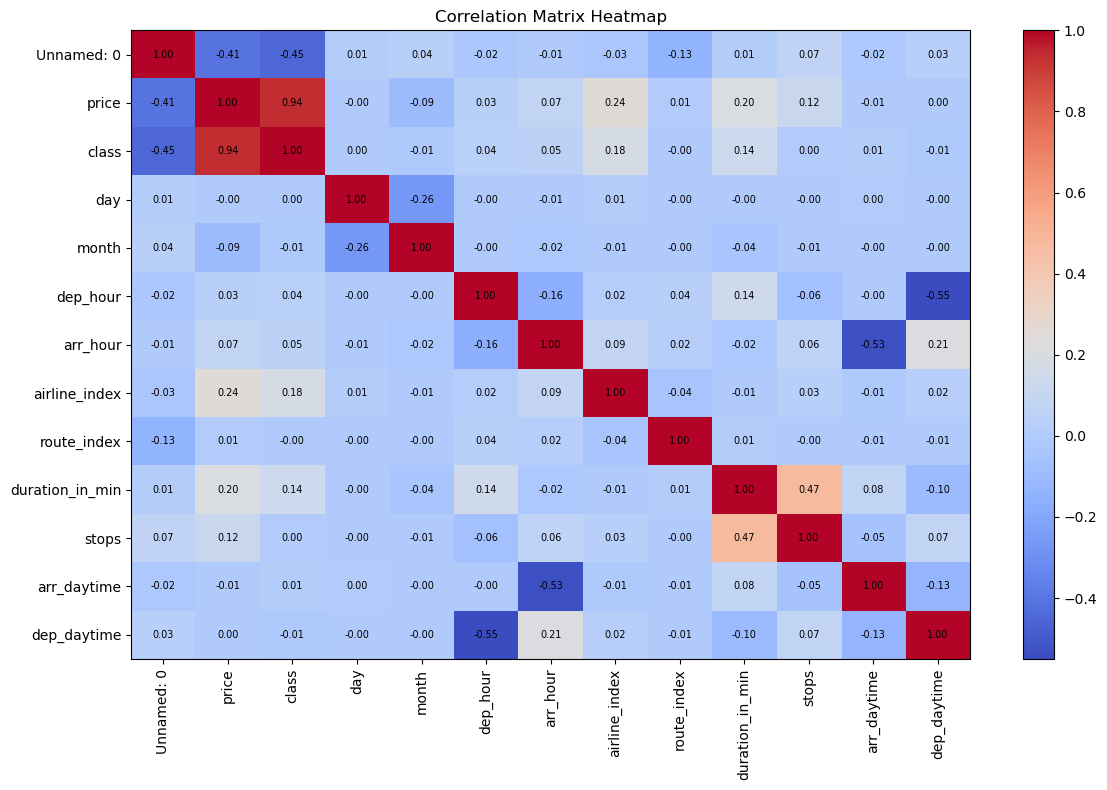

In [78]:
numeric_df = df.select_dtypes(include='number')
correlation = numeric_df.corr()

plt.figure(figsize=(12,8))
plt.imshow(correlation,cmap='coolwarm', aspect='auto')
plt.colorbar()

plt.xticks(range(len(correlation.columns)),correlation.columns,rotation=90)
plt.yticks(range(len(correlation.columns)),correlation.columns)

for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        plt.text(j,i, f"{correlation.iloc[i, j]:.2f}",
                 ha='center', va='center', fontsize=7)
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()



## Insight:
price and class have a very strong positive correlation of 0.94. This indicates that flight class is one of the most important factors associated with ticket price.

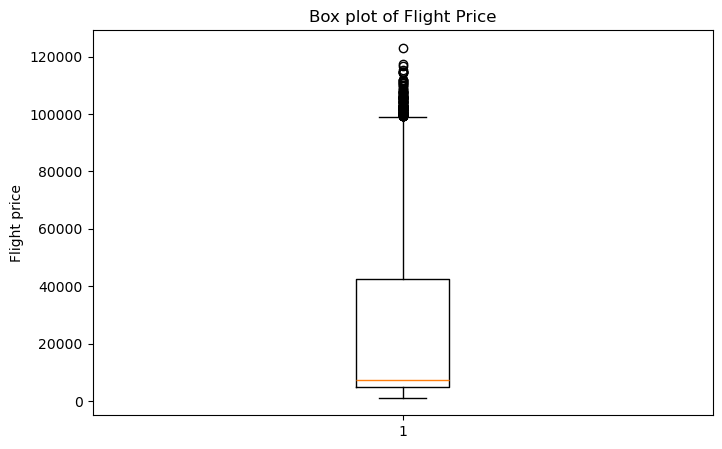

In [79]:
## price outliers

plt.figure(figsize=(8,5))
plt.boxplot(df['price'])
plt.ylabel('Flight price')
plt.title('Box plot of Flight Price')
plt.show()

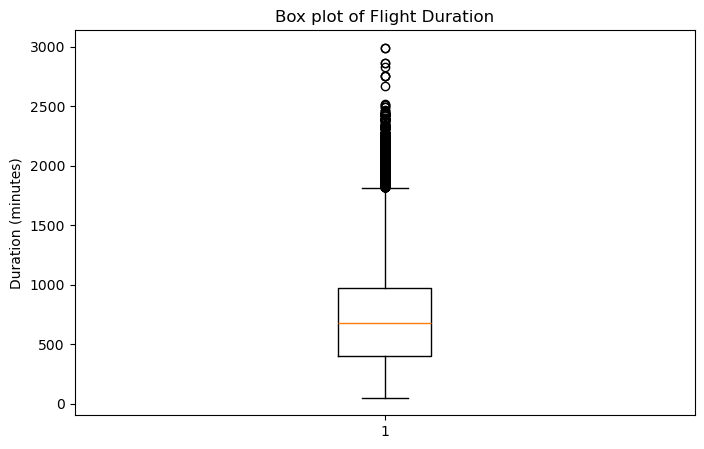

In [80]:
plt.figure(figsize=(8,5))
plt.boxplot(df['duration_in_min'])
plt.ylabel('Duration (minutes)')
plt.title('Box plot of Flight Duration')
plt.show()

## Insight
Both flight price and duration contain outliers. These high values may represent genuine expensive flights or long-duration flights, so they were not automatically removed.

In [81]:
df['Unnamed: 0'].head()

0    0
1    1
2    2
3    3
4    4
Name: Unnamed: 0, dtype: int64

In [82]:
df = df.drop('Unnamed: 0', axis=1)


In [83]:
df.shape

(300257, 24)

In [84]:
## check categorical columns

df.select_dtypes(include='object').columns

Index(['airline', 'from', 'to', 'class_category', 'flight_no', 'route',
       'dep_period', 'arr_period', 'stops_category', 'arr_daytime_category',
       'dep_daytime_category', 'month_category'],
      dtype='object')

In [85]:
## unique values check


for col in df.select_dtypes(include='object').columns:
    print(col, ":", df[col].nunique())

airline : 8
from : 6
to : 6
class_category : 2
flight_no : 1569
route : 30
dep_period : 4
arr_period : 4
stops_category : 3
arr_daytime_category : 2
dep_daytime_category : 2
month_category : 2


In [86]:
drop_cols = [
    'flight_no',
    'route',
    'airline_index',
    'route_index',
    'class',
    'stops_category',
    'arr_daytime_category',
    'dep_daytime_category',
    'month_category'
]

df = df.drop(columns=drop_cols)

In [87]:
df.shape

(300257, 15)

In [88]:
df.columns

Index(['airline', 'from', 'to', 'price', 'class_category', 'day', 'month',
       'dep_hour', 'arr_hour', 'dep_period', 'arr_period', 'duration_in_min',
       'stops', 'arr_daytime', 'dep_daytime'],
      dtype='object')

## Insight:
Redundant and less useful columns were removed to create a cleaner set of features for the regression model.

In [89]:
## Feture and target

X = df.drop('price', axis=1)
y = df['price']

In [90]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (300257, 14)
y shape: (300257,)


In [91]:
## Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [92]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (240205, 14)
X_test: (60052, 14)
y_train: (240205,)
y_test: (60052,)


In [93]:
## Numerical and categorical column separate

numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print("Numerical Columns:")
print(numeric_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
['day', 'month', 'dep_hour', 'arr_hour', 'duration_in_min', 'stops', 'arr_daytime', 'dep_daytime']

Categorical Columns:
['airline', 'from', 'to', 'class_category', 'dep_period', 'arr_period']


In [94]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_train_cat = encoder.fit_transform(X_train[categorical_cols])
X_test_cat = encoder.transform(X_test[categorical_cols])

print("Encoded training shape:", X_train_cat.shape)
print("Encoded testing shape:", X_test_cat.shape)

Encoded training shape: (240205, 30)
Encoded testing shape: (60052, 30)


In [95]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train[numeric_cols])
X_test_num = scaler.transform(X_test[numeric_cols])

print("Scaled training shape:", X_train_num.shape)
print("Scaled testing shape:", X_test_num.shape)

Scaled training shape: (240205, 8)
Scaled testing shape: (60052, 8)


In [96]:
import numpy as np

X_train_processed = np.hstack([X_train_num, X_train_cat])
X_test_processed = np.hstack([X_test_num, X_test_cat])

print("Final training shape:", X_train_processed.shape)
print("Final testing shape:", X_test_processed.shape)

Final training shape: (240205, 38)
Final testing shape: (60052, 38)


## Insight:
Categorical variables were converted into numerical form using One-Hot Encoding, and numerical variables were standardized using StandardScaler.

In [97]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train_processed, y_train)

y_pred_lr = lr.predict(X_test_processed)

print("Linear Regression completed")

Linear Regression completed


In [98]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression R² Score:", r2_lr)
print("Linear Regression RMSE:", rmse_lr)

Linear Regression R² Score: 0.9097784604327986
Linear Regression RMSE: 6833.416875549671


In [99]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_processed, y_train)

y_pred_rf = rf.predict(X_test_processed)

print("Random Forest completed")

Random Forest completed


In [100]:
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest R² Score:", r2_rf)
print("Random Forest RMSE:", rmse_rf)

Random Forest R² Score: 0.9884824293158793
Random Forest RMSE: 2441.536617447409


In [101]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)

gb.fit(X_train_processed, y_train)

y_pred_gb = gb.predict(X_test_processed)

print("Gradient Boosting completed")

Gradient Boosting completed


In [102]:
r2_gb = r2_score(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))

print("Gradient Boosting R² Score:", r2_gb)
print("Gradient Boosting RMSE:", rmse_gb)

Gradient Boosting R² Score: 0.9519715683820403
Gradient Boosting RMSE: 4985.767260158442


## Insight:
*Linear Regression achieved a good baseline, but its performance was lower than the tree-based models.
*Random Forest achieved the best performance, with an R² score of approximately 0.988, meaning it explains about 98.8% of the variation in flight prices.
*Gradient Boosting performed better than Linear Regression but was less accurate than Random Forest.


In [103]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor

In [104]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


In [105]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', dtype='float32'))
])

In [106]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

In [107]:
final_model = RandomForestRegressor(
    n_estimators=20,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', final_model)
])

## insight
A complete pipeline was created to combine preprocessing and model prediction into a single workflow. This makes the model easier to use during deployment.

In [108]:
final_pipeline.fit(X_train, y_train)

print("Final pipeline trained successfully!")

Final pipeline trained successfully!


In [109]:
y_pred_pipeline = final_pipeline.predict(X_test)

r2_pipeline = r2_score(y_test, y_pred_pipeline)
rmse_pipeline = np.sqrt(mean_squared_error(y_test, y_pred_pipeline))

print("Final Pipeline R² Score:", r2_pipeline)
print("Final Pipeline RMSE:", rmse_pipeline)

Final Pipeline R² Score: 0.9868586863963774
Final Pipeline RMSE: 2607.967582142443


## insight
A complete pipeline was created to combine preprocessing and model prediction into a single workflow. This makes the model easier to use during deployment.

In [110]:
import joblib

joblib.dump(final_pipeline, 'flight_price_pipeline.pkl')

print("Pipeline saved successfully!")

Pipeline saved successfully!


In [111]:
print(X.columns.tolist())

['airline', 'from', 'to', 'class_category', 'day', 'month', 'dep_hour', 'arr_hour', 'dep_period', 'arr_period', 'duration_in_min', 'stops', 'arr_daytime', 'dep_daytime']


In [112]:
import os 
print(os.getcwd())

C:\Users\BEST
